In [1]:
!pip install tensorflow

In [9]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, BatchNormalization, MaxPooling2D
from tensorflow.keras.models import Model

In [3]:
cifar = tf.keras.datasets.cifar10

In [4]:
(x_train,y_train),(x_test,y_test) = cifar.load_data()
# carrega o dataset
x_train,x_test = x_train /255.0,x_test / 255.0
#normaliza para 0-1
y_train,y_test = y_train.flatten(), y_test.flatten()
# vetoriza as classes
print(x_train.shape)
print(y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1974s 12us/step
(50000, 32, 32, 3)
(50000,)


In [5]:
K = len(set(y_train))
# pega quantas classes o datset tem
print('classes: ', K)

classes:  10


In [14]:
i =Input(shape=x_train[0].shape)

x = Conv2D(32, (3,3),activation='relu', padding='same')(i)
x=BatchNormalization()(x)
x= Conv2D(32, (3,3),activation='relu', padding='same')(x)
x=BatchNormalization()(x)
x=MaxPooling2D((2,2))(x)

x=Conv2D(64,(3,3),activation='relu', padding='same')(x)
x=BatchNormalization()(x)
x=Conv2D(64,(3,3), activation='relu', padding='same')(x)
x=BatchNormalization()(x)
x=MaxPooling2D((2,2))(x)

x=Conv2D(128,(3,3), activation='relu', padding='same')(x)
x=BatchNormalization()(x)
x=Conv2D(128,(3,3), activation='relu', padding='same')(x)
x=BatchNormalization()(x)
x=MaxPooling2D((2,2))(x)

x=Flatten()(x)
x=Dropout(rate=0.2)(x)
x=Dense(1024,activation='relu')(x)
x=Dropout(rate=0.2)(x)
x=Dense(K,activation='softmax')(x)

model=Model(i,x)

In [15]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
# adiciona os paremetros de otimizar os pesos da rede e mericas
r=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=50)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - accuracy: 0.5594 - loss: 1.2811 - val_accuracy: 0.6822 - val_loss: 0.9108
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7099 - loss: 0.8365 - val_accuracy: 0.7317 - val_loss: 0.7762
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7647 - loss: 0.6795 - val_accuracy: 0.7299 - val_loss: 0.8383
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8014 - loss: 0.5768 - val_accuracy: 0.7367 - val_loss: 0.8242
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8324 - loss: 0.4872 - val_accuracy: 0.7813 - val_loss: 0.6544
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8562 - loss: 0.4199 - val_accuracy: 0.8201 - val_loss: 0.5680
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8799 - loss: 0.3450 - val_accuracy: 0.8112 - val_loss: 0.6028
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8950 - loss: 

In [17]:
batch_size = 323 #quantas imagens irao ser criadas
data_generator=tf.keras.preprocessing.image.ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1)# atributos que modficarao as imagens
train_generator = data_generator.flow(x_train,y_train,batch_size)# gera imagens para os dados de treino
steps_per_epoch=x_train.shape[0] // batch_size
r=model.fit(train_generator,validation_data=(x_test,y_test),steps_per_epoch=steps_per_epoch,epochs=15)# treina o modelo com as novas imagens

Epoch 1/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 47s 248ms/step - accuracy: 0.8935 - loss: 0.3544 - val_accuracy: 0.8379 - val_loss: 0.6004
Epoch 2/15
  1/154 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.9009 - loss: 0.3227

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9009 - loss: 0.3227 - val_accuracy: 0.8386 - val_loss: 0.5994
Epoch 3/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 31s 201ms/step - accuracy: 0.9079 - loss: 0.2872 - val_accuracy: 0.8486 - val_loss: 0.5425
Epoch 4/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8978 - loss: 0.3160 - val_accuracy: 0.8486 - val_loss: 0.5412
Epoch 5/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 32s 207ms/step - accuracy: 0.9170 - loss: 0.2574 - val_accuracy: 0.8487 - val_loss: 0.5383
Epoch 6/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8916 - loss: 0.3001 - val_accuracy: 0.8488 - val_loss: 0.5378
Epoch 7/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 30s 196ms/step - accuracy: 0.9223 - loss: 0.2377 - val_accuracy: 0.8495 - val_loss: 0.5248
Epoch 8/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9319 - loss: 0.2142 - val_accuracy: 0.8498 - val_loss: 0.5243
Epoch 9/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 38s 248ms/step - accuracy: 0.9271 - loss: 0.2214 - val_accuracy: 0

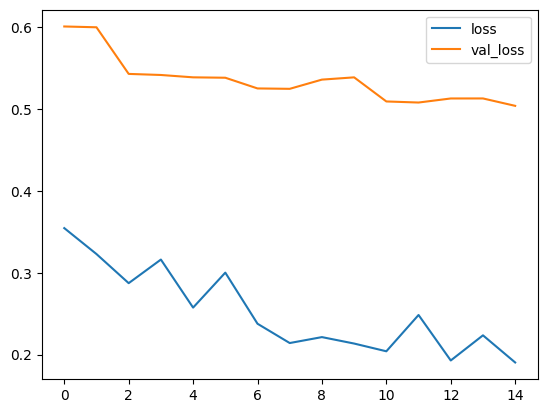

In [18]:
plt.plot(r.history['loss'],label='loss')
plt.plot(r.history['val_loss'],label='val_loss')
plt.legend()

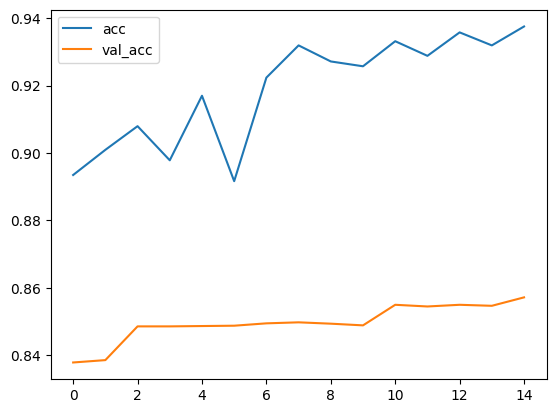

In [19]:
plt.plot(r.history['accuracy'],label='acc')
plt.plot(r.history['val_accuracy'],label='val_acc')
plt.legend()
# a rede sofre com um overfitting, podemos observar isso no treino onde sua acuracia é de 98% e nos testes é 84%

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


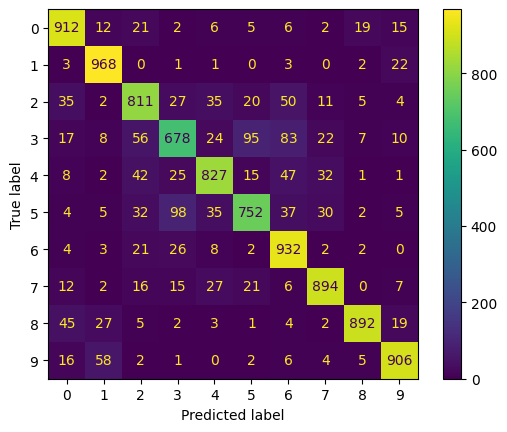

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
# podemos

matrix = ConfusionMatrixDisplay(confusion_matrix=cm)
matrix.plot()
plt.show()